In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv("/Users/prerana/Documents/Marketing_Conversion_Analytics/data/marketing_conversion.csv")
df.head()


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 8000
Columns: 20
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchas

In [7]:
#Missing values
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

In [8]:
#Descriptive statistics
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


In [9]:
#Overall conversion rate
conversion_rate = df["Conversion"].mean() * 100

print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Overall Conversion Rate: 87.65%


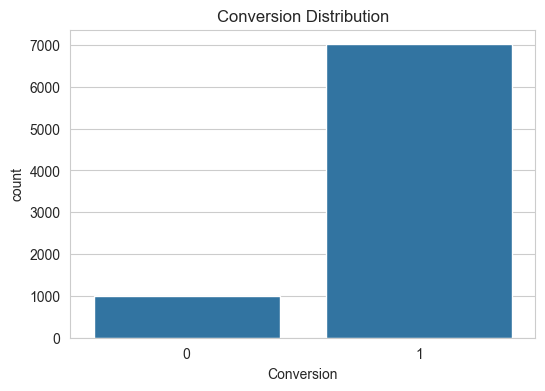

In [10]:
#Conversion distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Conversion"
)

plt.title("Conversion Distribution")
plt.show()

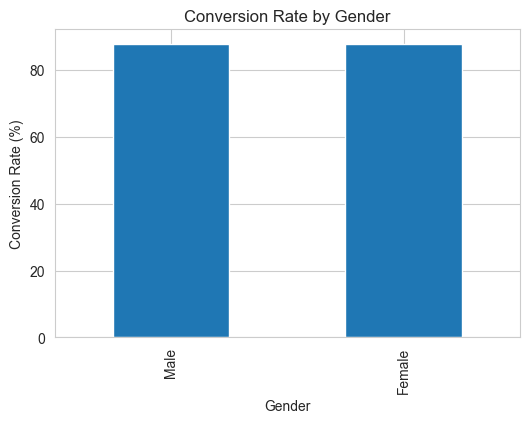

In [12]:
#Conversion by gender
gender_conversion = (
    df.groupby("Gender")["Conversion"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

gender_conversion

gender_conversion.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Conversion Rate by Gender")
plt.ylabel("Conversion Rate (%)")
plt.show()

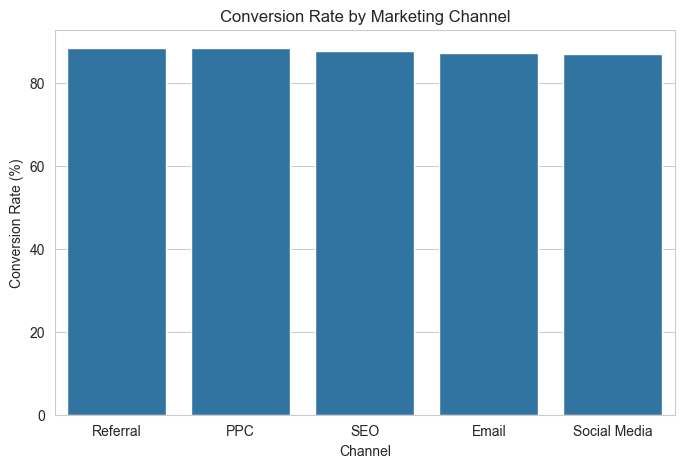

In [13]:
#Channel Performance
channel_conversion = (
    df.groupby("CampaignChannel")["Conversion"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

channel_conversion

plt.figure(figsize=(8,5))

sns.barplot(
    x=channel_conversion.index,
    y=channel_conversion.values
)

plt.title("Conversion Rate by Marketing Channel")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Channel")

plt.show()

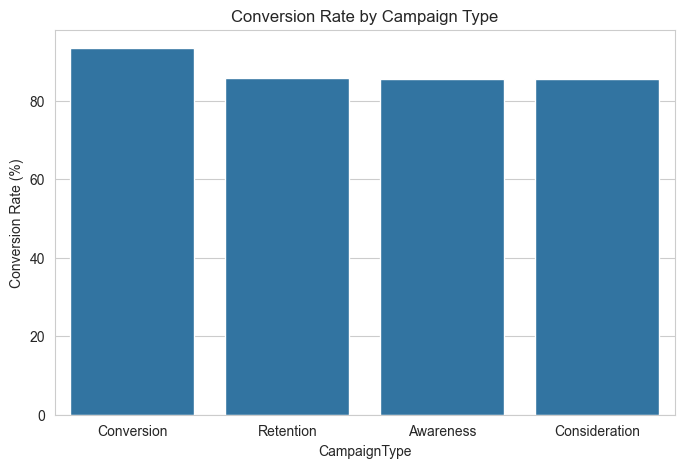

In [14]:
#Campaign type performance
campaign_conversion = (
    df.groupby("CampaignType")["Conversion"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

campaign_conversion

plt.figure(figsize=(8,5))

sns.barplot(
    x=campaign_conversion.index,
    y=campaign_conversion.values
)

plt.title("Conversion Rate by Campaign Type")
plt.ylabel("Conversion Rate (%)")

plt.show()

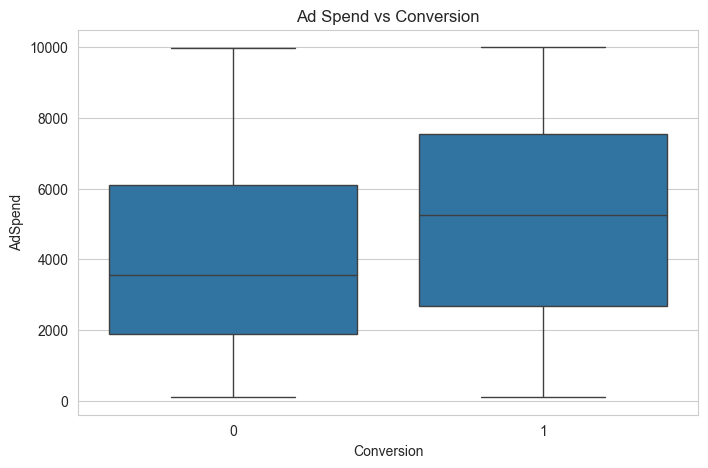

In [15]:
#Ad spend Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Conversion",
    y="AdSpend"
)

plt.title("Ad Spend vs Conversion")

plt.show()

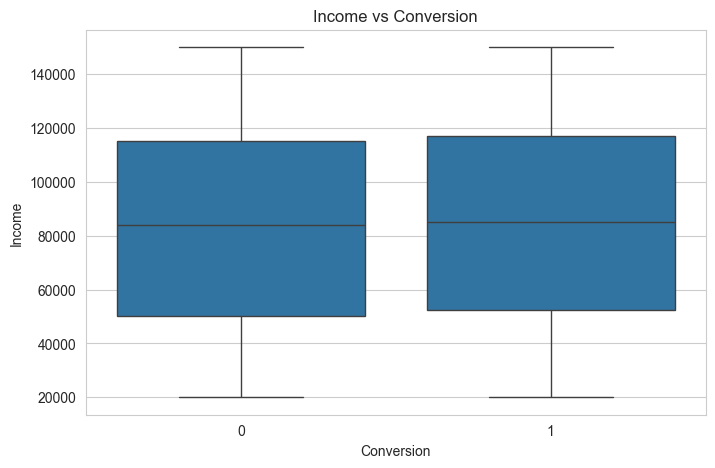

In [16]:
#Income Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Conversion",
    y="Income"
)

plt.title("Income vs Conversion")

plt.show()

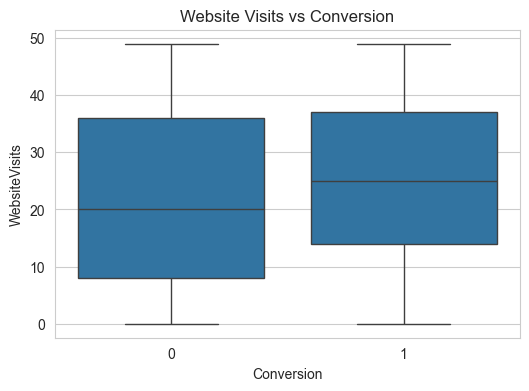

In [17]:
#Website visits analysis
website_visits = (
    df.groupby("Conversion")["WebsiteVisits"]
      .mean()
)

website_visits

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Conversion",
    y="WebsiteVisits"
)

plt.title("Website Visits vs Conversion")

plt.show()

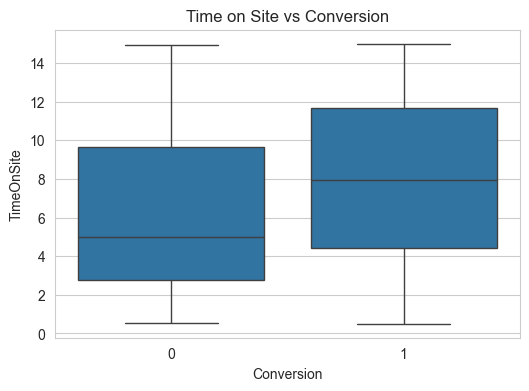

In [18]:
#Time on site analysis
time_analysis = (
    df.groupby("Conversion")["TimeOnSite"]
      .mean()
)

time_analysis

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Conversion",
    y="TimeOnSite"
)

plt.title("Time on Site vs Conversion")

plt.show()

In [19]:
#Email Engagement
email_metrics = (
    df.groupby("Conversion")[
        ["EmailOpens", "EmailClicks"]
    ].mean()
)

email_metrics

,EmailOpens,EmailClicks
Conversion,,
0,7.576923,3.481781
1,9.744581,4.606246


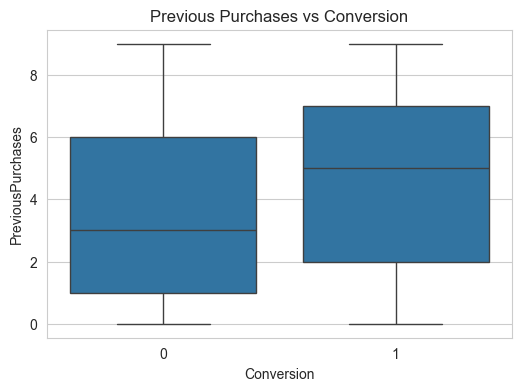

In [20]:
#Previous purchases
purchase_metrics = (
    df.groupby("Conversion")[
        "PreviousPurchases"
    ].mean()
)

purchase_metrics

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Conversion",
    y="PreviousPurchases"
)

plt.title("Previous Purchases vs Conversion")

plt.show()

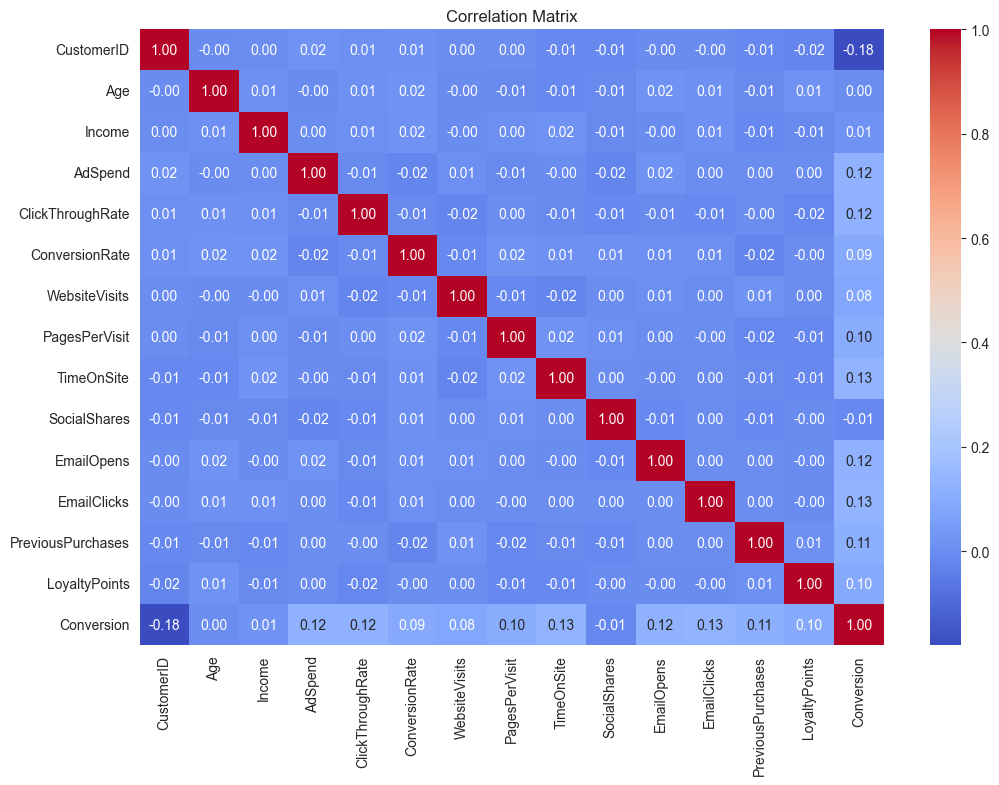

In [21]:
#Correlation map
numeric_cols = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [22]:
#Top conversion drivers
corr = (
    numeric_cols.corr()["Conversion"]
      .sort_values(ascending=False)
)

corr

Conversion           1.000000
TimeOnSite           0.129609
EmailClicks          0.129521
EmailOpens           0.124884
AdSpend              0.124672
ClickThroughRate     0.120012
PreviousPurchases    0.111781
PagesPerVisit        0.102840
LoyaltyPoints        0.095004
ConversionRate       0.093185
WebsiteVisits        0.079339
Income               0.013974
Age                  0.001606
SocialShares        -0.011449
CustomerID          -0.180742
Name: Conversion, dtype: float64

In [23]:
#Business Insights Summary
print("""
Key Insights:

1. Highest converting marketing channel: Referral
2. Highest converting campaign type: Conversion
3. Customers with more website visits convert more frequently.
4. Email engagement is positively associated with conversion.
5. Previous purchases and loyalty points appear to increase conversion likelihood.
""")


Key Insights:

1. Highest converting marketing channel: Referral
2. Highest converting campaign type: Conversion
3. Customers with more website visits convert more frequently.
4. Email engagement is positively associated with conversion.
5. Previous purchases and loyalty points appear to increase conversion likelihood.

